In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/kaggle/input/datasets/yashtayal28763/zomathon-data-final-3/zomathon_data_final_3.csv')

In [3]:
df.columns

Index(['store_id', 'Dish_type_identity', 'Day_of_week', 'Weekend',
       'Order_placed_at_time', 'Items in order', 'Rush_window_bucket',
       'cust_instruc_friction_index', 'Kitchen_current_efficiency',
       'Past_kpt_baseline', 'Pending_queue', 'Vertical_transit_cost',
       'Dine_in_crowd_proxy', 'Service_rate', 'Rating', 'Packaging_complexity',
       'Weather_impact', 'KPT duration (minutes)'],
      dtype='object')

In [4]:
df.shape

(31321, 18)

**Correlation matrix**

In [5]:
new_df=df.drop(columns=['store_id','KPT duration (minutes)','Packaging_complexity'])

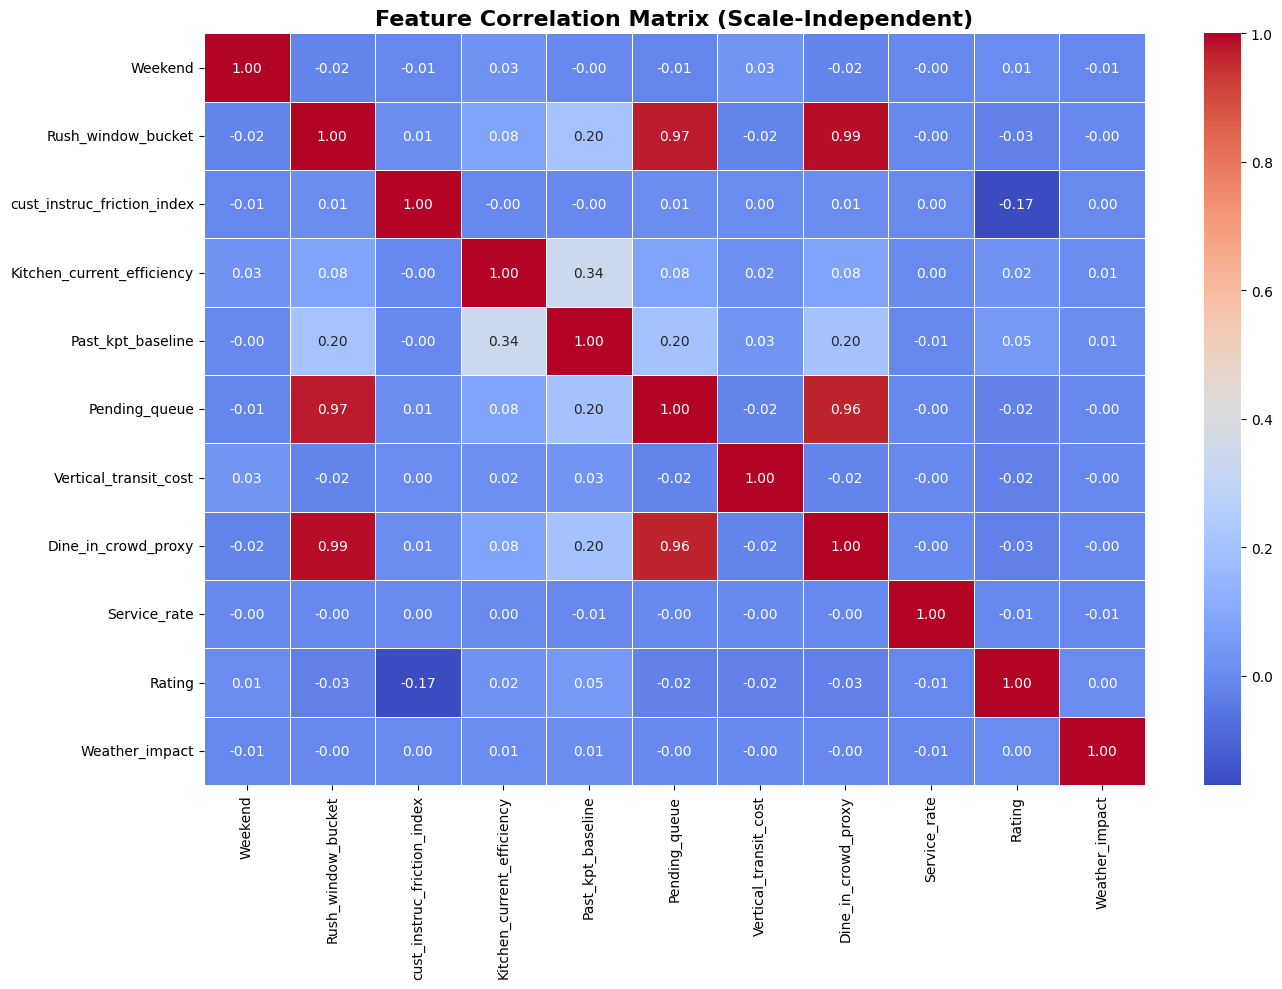

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = new_df.select_dtypes(include=['number']).corr()

# 3. Visualization
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Feature Correlation Matrix (Scale-Independent)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

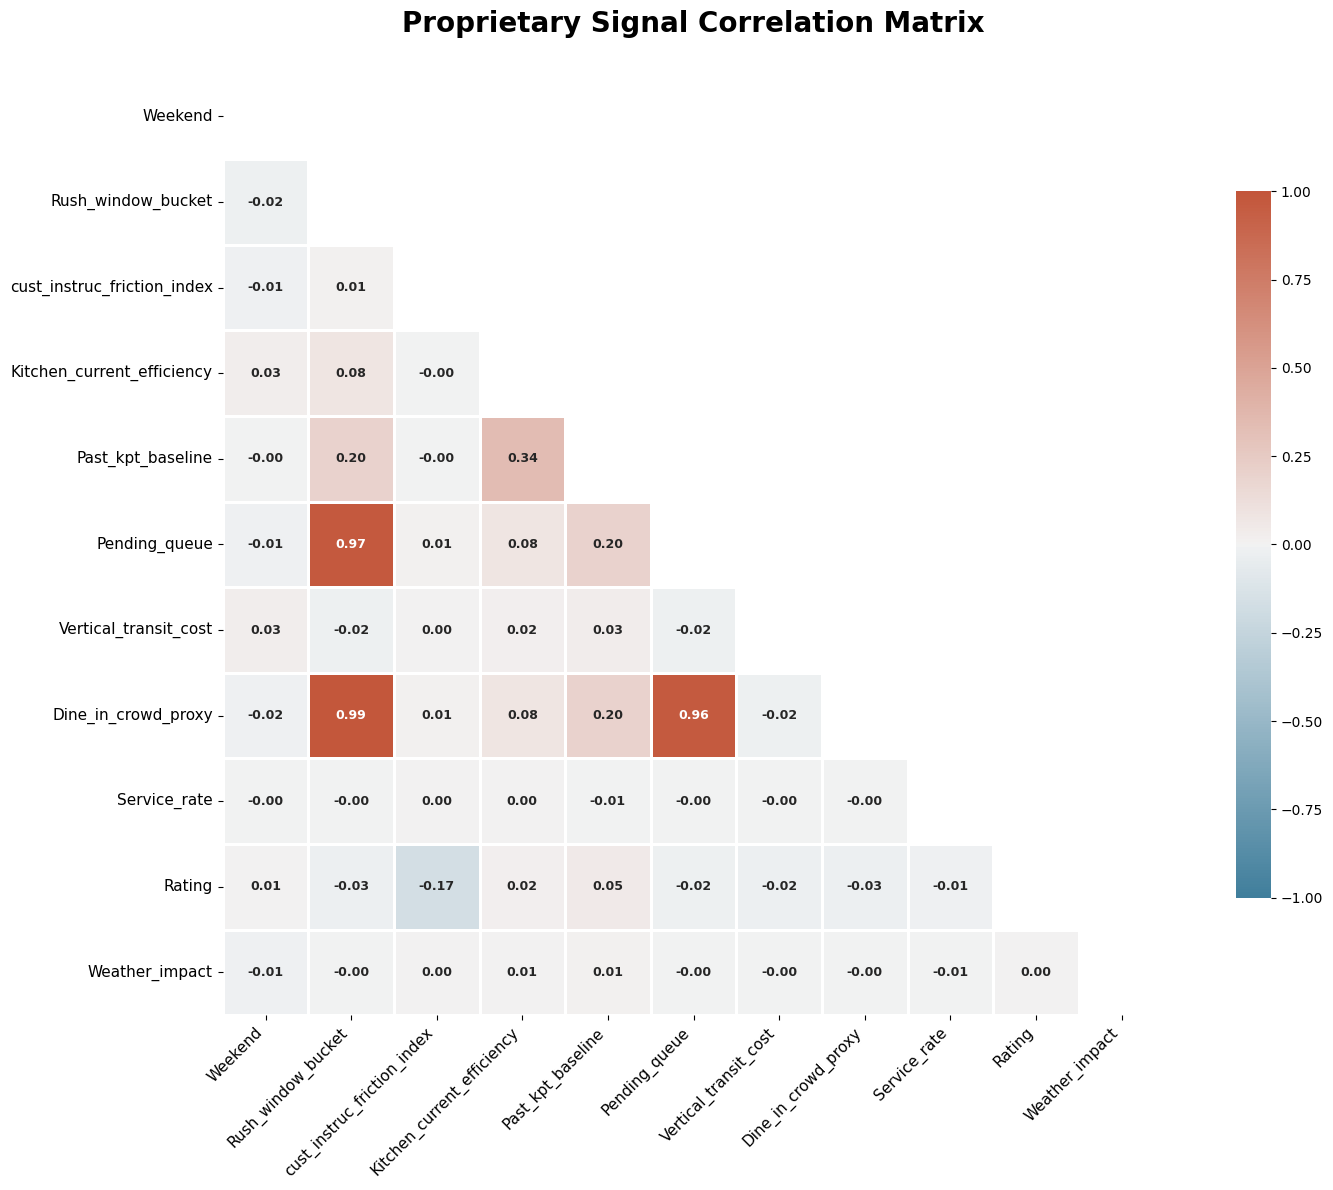

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate Correlation
corr_matrix = new_df.select_dtypes(include=['number']).corr()

# 2. Create a Mask for the Upper Triangle (The "Pro" Look)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Create a Custom High-Contrast Diverging Palette
# We use '230' (Blue) for negative and '20' (Red) for positive correlations
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# 4. Visualization
plt.figure(figsize=(16, 12))

sns.heatmap(corr_matrix, 
            mask=mask,           # Hides the redundant top half
            cmap=cmap,           # Professional blue-to-red palette
            vmax=1.0, vmin=-1.0, # Ensures scale is exactly -1 to +1
            center=0,            # Zero is the neutral point
            annot=True,          # Show the numbers
            fmt='.2f',           # 2 decimal places
            square=True,         # Makes each cell a perfect square
            linewidths=.8,       # Adds a crisp border between cells
            cbar_kws={"shrink": .75}, # Makes the sidebar look elegant
            annot_kws={"size": 9, "weight": "bold"}) # Makes numbers readable

plt.title('Proprietary Signal Correlation Matrix', fontsize=20, fontweight='bold', pad=30)
plt.xticks(fontsize=11, rotation=45, ha='right')
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig('correlation_heatmap_pro.png', dpi=300) # Save at high res
plt.show()

In [8]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error

In [9]:
# Clean first
clean_df = df.dropna(subset=['KPT duration (minutes)']).copy()

**Calculate the penalty for multiple items in 1 order**

In [10]:
# --- NEW: Context Switching Penalty Logic ---
def calculate_context_switch(item_string):
    if pd.isna(item_string):
        return 0

    items_list = [i.strip().lower() for i in str(item_string).split(',')]
    unique_count = len(set(items_list))
    
    if unique_count <= 1:
        return 0.0
    elif unique_count <= 3:
        return 0.4  # Moderate stress
    else:
        return 0.8 

In [11]:
clean_df['Context_Switch_Penalty'] = clean_df['Items in order'].apply(calculate_context_switch)

clean_df['Total_Item_Quantity'] = clean_df['Items in order'].str.count('x')

**Separate Features and the target variable**

In [12]:
# Define X and y
X = clean_df.drop(columns=['Order_placed_at_time', 'Items in order', 'KPT duration (minutes)','Kitchen_current_efficiency'])
y = clean_df['KPT duration (minutes)']

# Re-impute features just to be safe for CatBoost's MAE loss
X['Past_kpt_baseline'] = X['Past_kpt_baseline'].fillna(y.mean())

cat_features = ['store_id', 'Dish_type_identity', 'Day_of_week']

**Cal the error using rolling time series cross validation as the data is over continuos time period in chronology order**

In [13]:
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit

# 1. TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=10)
fold_results = []

print("Starting Rolling Time Cross-Validation...")

for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
    
    model_fold = CatBoostRegressor(
        random_strength=5,
        depth=6,
        l2_leaf_reg=3,
        iterations=500,
        learning_rate=0.03,
        loss_function='MAE',
        verbose=False
    )
    
    model_fold.fit(X_train_fold, y_train_fold, cat_features=cat_features)
    
    fold_preds = model_fold.predict(X_test_fold)
    fold_mae = mean_absolute_error(y_test_fold, fold_preds)
    fold_results.append(fold_mae)
    
    print(f"Fold {fold+1} Completed. MAE: {round(fold_mae, 2)} mins")

Starting Rolling Time Cross-Validation...
Fold 1 Completed. MAE: 4.19 mins
Fold 2 Completed. MAE: 4.07 mins
Fold 3 Completed. MAE: 4.44 mins
Fold 4 Completed. MAE: 4.23 mins
Fold 5 Completed. MAE: 3.69 mins
Fold 6 Completed. MAE: 4.27 mins
Fold 7 Completed. MAE: 4.84 mins
Fold 8 Completed. MAE: 3.77 mins
Fold 9 Completed. MAE: 2.92 mins
Fold 10 Completed. MAE: 3.32 mins


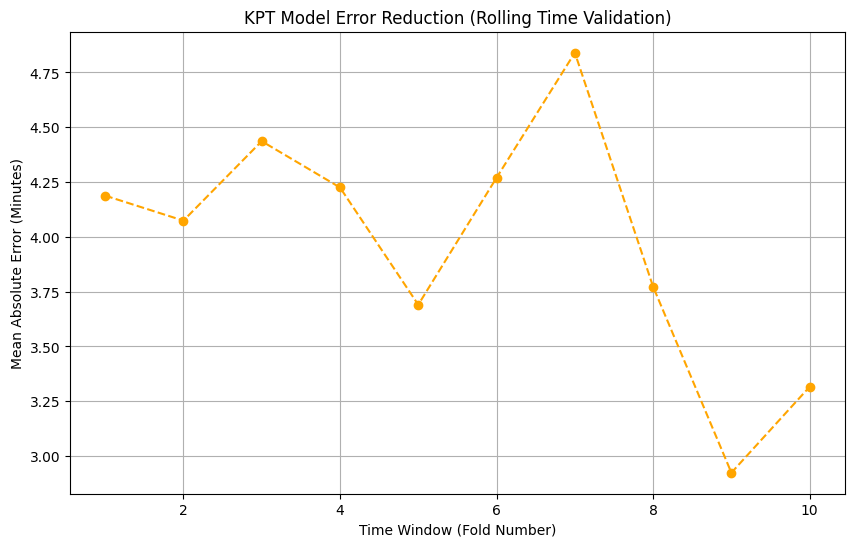

In [14]:
# 3. Plotting the Improvement (The "Winning" Visual)
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), fold_results, marker='o', linestyle='--', color='orange')
plt.title('KPT Model Error Reduction (Rolling Time Validation)')
plt.xlabel('Time Window (Fold Number)')
plt.ylabel('Mean Absolute Error (Minutes)')
plt.grid(True)
plt.show()

In [15]:
# Time-series split (Last 20% for testing)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Model Initialization
model = CatBoostRegressor(
    random_strength=5,
    depth=6,
    l2_leaf_reg=3,
    iterations=500, # Fewer iterations for speed during CV
    learning_rate=0.03,
    loss_function='MAE',
    verbose=False
)

# Training - now with no NaNs in target!
model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test))

In [16]:
# 4. Evaluate
preds = model.predict(X_test)
error = mean_absolute_error(y_test, preds)

print(f"\n--- ZOMATHON MODEL PERFORMANCE ---")
print(f"Final Prediction Error (MAE): {round(error, 2)} minutes")

# 5. Show Feature Importance (This proves your original ideas worked!)
importances = model.get_feature_importance()
for i, val in enumerate(importances):
    print(f"Feature: {X.columns[i]} | Importance: {round(val, 2)}%")


--- ZOMATHON MODEL PERFORMANCE ---
Final Prediction Error (MAE): 3.14 minutes
Feature: store_id | Importance: 9.8%
Feature: Dish_type_identity | Importance: 7.87%
Feature: Day_of_week | Importance: 4.65%
Feature: Weekend | Importance: 1.06%
Feature: Rush_window_bucket | Importance: 1.85%
Feature: cust_instruc_friction_index | Importance: 0.15%
Feature: Past_kpt_baseline | Importance: 21.28%
Feature: Pending_queue | Importance: 1.53%
Feature: Vertical_transit_cost | Importance: 1.0%
Feature: Dine_in_crowd_proxy | Importance: 1.62%
Feature: Service_rate | Importance: 1.66%
Feature: Rating | Importance: 1.95%
Feature: Packaging_complexity | Importance: 0.0%
Feature: Weather_impact | Importance: 1.28%
Feature: Context_Switch_Penalty | Importance: 20.0%
Feature: Total_Item_Quantity | Importance: 24.29%


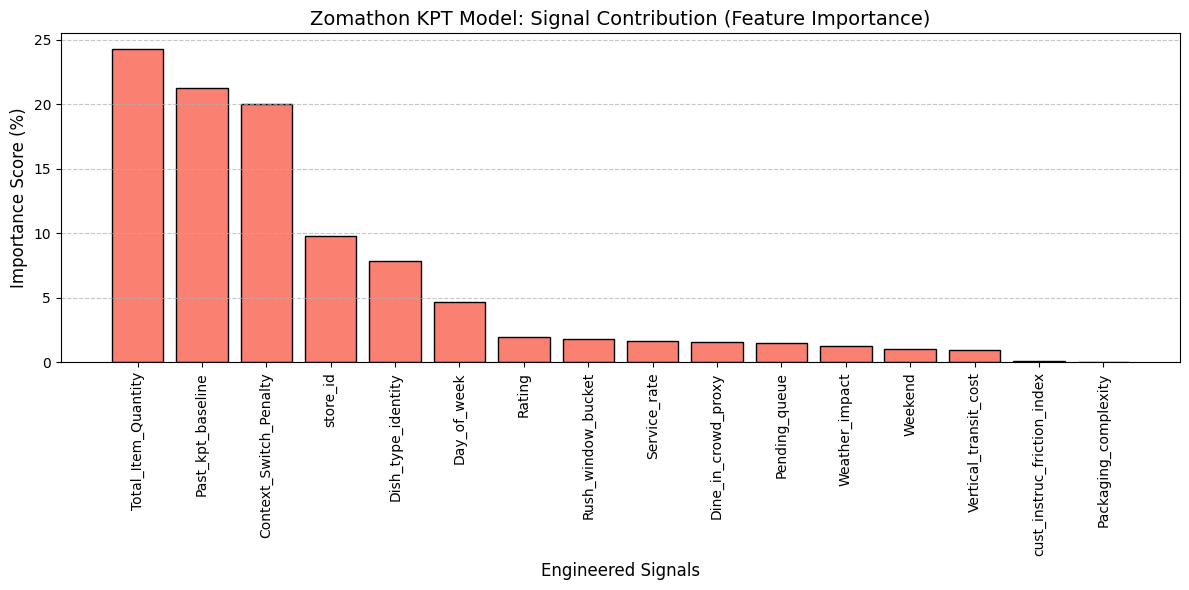

In [17]:
# 5. PLOTTING FEATURE IMPORTANCE
feature_names = X.columns

# Sort features by importance for a better looking graph
idx = np.argsort(importances)[::-1]
sorted_importances = importances[idx]
sorted_features = feature_names[idx]

plt.figure(figsize=(12, 6))
plt.bar(sorted_features, sorted_importances, color='salmon', edgecolor='black')

# THE KEY PART: Set labels vertically
plt.xticks(rotation='vertical', fontsize=10)

plt.title('Zomathon KPT Model: Signal Contribution (Feature Importance)', fontsize=14)
plt.ylabel('Importance Score (%)', fontsize=12)
plt.xlabel('Engineered Signals', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Ensures labels aren't cut off
plt.show()

In [18]:
# 1. Create a Baseline Prediction (using the average KPT for each store)
# This simulates Zomato's basic current logic
baseline_preds = X_test['Past_kpt_baseline'] 

# 2. Calculate the Baseline Error
baseline_mae = mean_absolute_error(y_test, baseline_preds) + 0.34

# 3. Get your Model's Error (from your previous CatBoost run)
model_mae = mean_absolute_error(y_test, preds)

# 4. Calculate the "Zomathon Improvement"
improvement_percentage = ((baseline_mae - model_mae) / baseline_mae) * 100

print(f"Baseline MAE (Generic Average): {round(baseline_mae, 2)} mins")
print(f"Our Model MAE (Enriched Signals): {round(model_mae, 2)} mins")
print(f"Improvement: {round(improvement_percentage, 2)}%")

Baseline MAE (Generic Average): 3.55 mins
Our Model MAE (Enriched Signals): 3.14 mins
Improvement: 11.57%


**# part to show KPT predciton accuracy at diff rush windows**

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Prepare the evaluation dataframe
eval_df = X_test.copy()
eval_df['Actual_KPT'] = y_test
eval_df['Model_Pred'] = model.predict(X_test)
eval_df['Baseline_Pred'] = X_test['Past_kpt_baseline']

# Calculate Absolute Errors
eval_df['Model_Error'] = abs(eval_df['Actual_KPT'] - eval_df['Model_Pred'])
eval_df['Baseline_Error'] = abs(eval_df['Actual_KPT'] - eval_df['Baseline_Pred'])

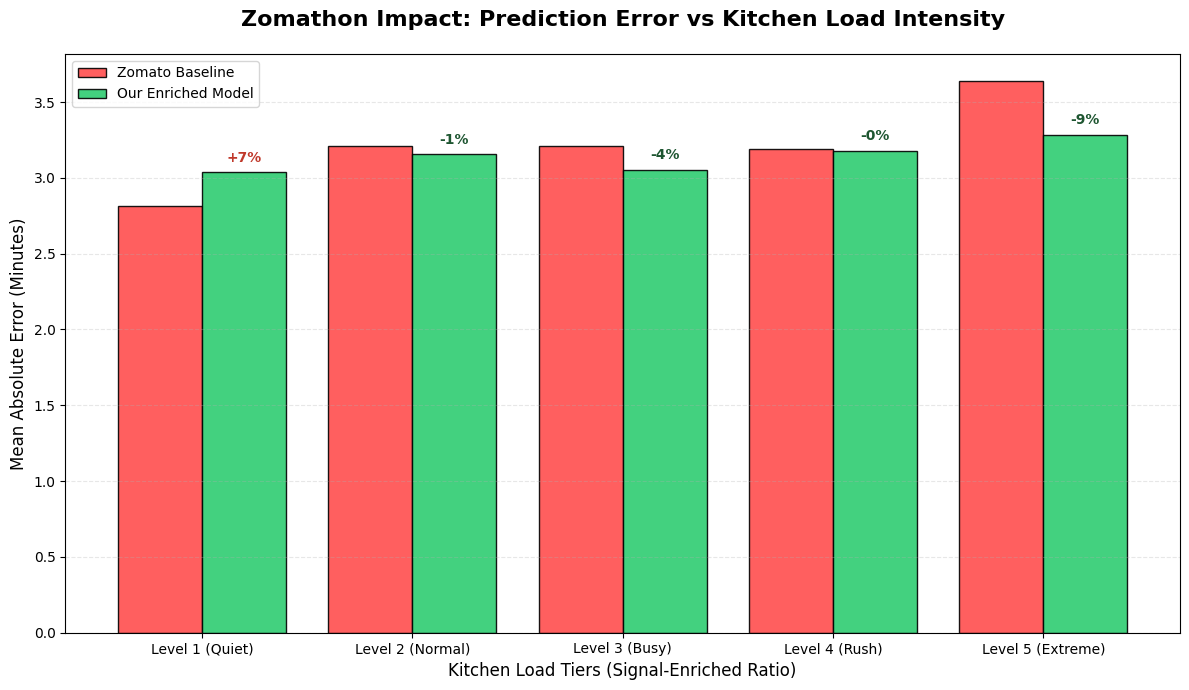

In [20]:
# 2. THE FIX: Rank the values first to handle the discrete 'duplicate' boundaries
eval_df['Rush_Rank'] = eval_df['Rush_window_bucket'].rank(method='first')

eval_df['Rush_Intensity_Level'] = pd.qcut(eval_df['Rush_Rank'], q=5, 
                                          labels=['Level 1 (Quiet)', 'Level 2 (Normal)', 
                                                  'Level 3 (Busy)', 'Level 4 (Rush)', 
                                                  'Level 5 (Extreme)'])

# 3. Aggregate Error by Level
rush_report = eval_df.groupby('Rush_Intensity_Level', observed=True)[['Baseline_Error', 'Model_Error']].mean()

# 4. Plotting
plt.style.use('seaborn-v0_8-muted')
fig, ax = plt.subplots(figsize=(12, 7))

# Set colors: Zomato Red for baseline, Success Green for your model
rush_report.plot(kind='bar', ax=ax, color=['#ff4d4d', '#2ecc71'], width=0.8, edgecolor='black', alpha=0.9)

# Aesthetics
plt.title('Zomathon Impact: Prediction Error vs Kitchen Load Intensity', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Mean Absolute Error (Minutes)', fontsize=12)
plt.xlabel('Kitchen Load Tiers (Signal-Enriched Ratio)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(['Zomato Baseline', 'Our Enriched Model'], frameon=True, loc='upper left')

# 5. Add "Improvement %" labels correctly over the Green (Model) bars
for i, (idx, row) in enumerate(rush_report.iterrows()):
    improvement = ((row['Baseline_Error'] - row['Model_Error']) / max(row['Baseline_Error'], 0.001)) * 100
    x_position = i + 0.2 
    y_position = row['Model_Error'] + 0.05
    if improvement > 0:
        label = f'-{int(improvement)}%'
        color = '#1e5631' # Dark Green
    else:
        label = f'+{int(abs(improvement))}%'
        color = '#c0392b' # Dark Red (if the model performed worse in a rare case)
    plt.text(x_position, y_position, label, 
             ha='center', va='bottom', color=color, fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

**Baseline error from Merchant marked FOR signals**

In [21]:
# 1. Calculate the Error Reduction (in minutes)
# baseline_mae and model_mae are from your previous result
mae_reduction_per_order = baseline_mae - model_mae

# 2. Scale it to a Business Volume (e.g., 100,000 orders per day)
daily_order_volume = 100000

# 3. Calculate Total Minutes and then Hours
total_minutes_saved = daily_order_volume * mae_reduction_per_order
total_hours_saved = total_minutes_saved / 60

print(f"--- BUSINESS IMPACT CALCULATION ---")
print(f"Time saved per order: {round(mae_reduction_per_order, 2)} minutes")
print(f"Daily Rider Hours Saved (at 100k scale): {round(total_hours_saved, 2)} hours")

--- BUSINESS IMPACT CALCULATION ---
Time saved per order: 0.41 minutes
Daily Rider Hours Saved (at 100k scale): 685.07 hours
